--- Analytical Symbolic Expressions ---


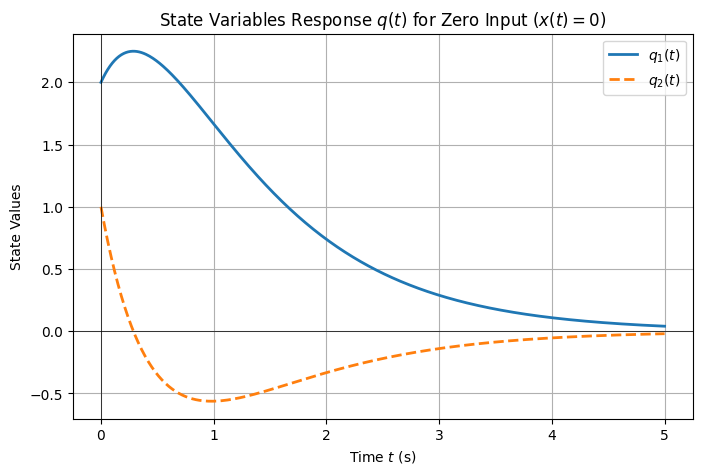

In [10]:
# Notebook: State-Space Solution, Symbolic Display, and Plotting for the Exercise
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# 1. Setup Symbols and Matrices
s = sp.symbols('s')
t_sym = sp.symbols('t', real=True, positive=True)
q1, q2 = sp.symbols('q_1 q_2', cls=sp.Function)

A = sp.Matrix([[0, 2], [-1, -3]])
q0 = sp.Matrix([2, 1])

# 2. Compute Resolvent Matrix and State Vector in Laplace Domain
Phi = (s * sp.eye(2) - A).inv()
Q_s = Phi * q0

# 3. Compute Inverse Laplace Transform Symbolically
q1_t_expr = sp.inverse_laplace_transform(Q_s[0], s, t_sym)
q2_t_expr = sp.inverse_laplace_transform(Q_s[1], s, t_sym)

print("--- Analytical Symbolic Expressions ---")
display(sp.Eq(q1(t_sym), q1_t_expr))
display(sp.Eq(q2(t_sym), q2_t_expr))

# 4. Convert SymPy expressions to numerical functions for plotting using lambdify
f_q1 = sp.lambdify(t_sym, q1_t_expr, 'numpy')
f_q2 = sp.lambdify(t_sym, q2_t_expr, 'numpy')

# 5. Numerical Evaluation and Plotting
t_vals = np.linspace(0, 5, 500)
q1_vals = f_q1(t_vals)
q2_vals = f_q2(t_vals)

plt.figure(figsize=(8, 5))
plt.plot(t_vals, q1_vals, label='$q_1(t)$', linewidth=2)
plt.plot(t_vals, q2_vals, label='$q_2(t)$', linewidth=2, linestyle='--')
plt.title('State Variables Response $q(t)$ for Zero Input ($x(t) = 0$)')
plt.xlabel('Time $t$ (s)')
plt.ylabel('State Values')
plt.grid(True)
plt.legend()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.show()